# Chapter 5 — Exercises

Exercises for Chapter 5 of *Bayesian Analysis with Python* (3rd edition).

## Set-up

### Imports

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

import const

### Defaults

In [2]:
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(const.RANDOM_SEED)

### Constants

In [3]:
ORDER = 5
N_PP_SAMPLES = 100

# prior standard deviation for beta, one entry per model
BETA_SIGMAS = {
    "β sd=1": 1.0,
    "β sd=100": 100.0,
    "β sd=[10, 0.1, ...]": np.array([10.0, 0.1, 0.1, 0.1, 0.1]),
}

## Load data

`dummy.csv` is two whitespace-separated columns with no header: a predictor `x` and a response `y`.

In [4]:
dummy = pd.read_csv(const.DUMMY_DATA_PATH, sep=r"\s+", header=None, names=["x", "y"])
dummy.head()

,x,y
0,-1.081,9.357
1,-0.888,8.322
2,-0.623,8.745
3,-0.480,7.346
4,-0.505,7.028


## Exercise 1 — Regularization priors

Fit a quintic (order 5) polynomial to the dummy data under three priors for the coefficients β, holding α ~ Normal(0, 1) and σ ~ Exponential(scale=5) fixed.
As in the chapter notes, each polynomial feature $x^i$ and the response are standardised before fitting.
The three priors trade flexibility against regularization:

- **β sd=1** — mild regularization, all orders shrunk toward zero equally.
- **β sd=100** — near-flat, letting the high-order terms run free.
- **β sd=[10, 0.1, 0.1, 0.1, 0.1]** — loose on the linear term, tight on the higher orders.

The models share the likelihood and differ only in the β prior:

\begin{align*}
\alpha &\sim \mathcal{N}(0, 1) \\
\beta_i &\sim \mathcal{N}(0, s_i) \\
\sigma &\sim \text{Exponential}(\text{scale}=5) \\
\mu &= \alpha + \sum_{i=1}^{5} \beta_i \, \tilde{x}_i \\
y &\sim \mathcal{N}(\mu, \sigma)
\end{align*}

where $\tilde{x}_i$ is the standardised $x^i$ and $s_i$ is the prior sd (scalar or per-order).

### Prepare features

Standardise each polynomial feature and the response once; the standardisation is shared across all three models.

In [5]:
x = dummy["x"].to_numpy()
y = dummy["y"].to_numpy()

x_p = np.vstack([x**i for i in range(1, ORDER + 1)])
x_mean = x_p.mean(axis=1, keepdims=True)
x_std = x_p.std(axis=1, keepdims=True)
x_c = (x_p - x_mean) / x_std
y_c = (y - y.mean()) / y.std()

### Fit

One quintic model per β prior. `beta_sigma` is a scalar for the flat priors and a length-5 vector for the per-order prior.

In [6]:
def fit_quintic(beta_sigma):
    coords = {"poly": range(ORDER), "obs": range(len(y_c))}
    with pm.Model(coords=coords) as model:
        # data
        X = pm.Data("X", x_c, dims=("poly", "obs"))

        # priors
        alpha = pm.Normal("alpha", mu=0, sigma=1)
        beta = pm.Normal("beta", mu=0, sigma=beta_sigma, dims="poly")
        sigma = pm.Exponential("sigma", scale=5)

        # likelihood
        mu = alpha + pm.math.dot(beta, X)
        pm.Normal("y", mu=mu, sigma=sigma, observed=y_c, dims="obs")

        # sample
        idata = pm.sample(draws=1000, chains=4, random_seed=const.RANDOM_SEED)
        pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=const.RANDOM_SEED)

    return idata

In [7]:
idatas = {name: fit_quintic(bs) for name, bs in BETA_SIGMAS.items()}

NUTS[nutpie]: [alpha, beta, sigma]


Output()

Sampling: [y]


Output()

NUTS[nutpie]: [alpha, beta, sigma]


...

Output()

NUTS[nutpie]: [alpha, beta, sigma]


Output()

Sampling: [y]


Output()

### Convergence checks

Want `r_hat < 1.01`, `ess_bulk > 400`, and zero divergences before reading anything into the fits.

In [8]:
rows = {}
for name, idata in idatas.items():
    summ = az.summary(idata, var_names=["alpha", "beta", "sigma"])
    rows[name] = {
        "max_r_hat": summ["r_hat"].max(),
        "min_ess_bulk": summ["ess_bulk"].min(),
        "divergences": int(idata.sample_stats["diverging"].sum()),
    }
checks = pd.DataFrame(rows).T
checks.index.name = "model"
checks

,max_r_hat,min_ess_bulk,divergences
model,,,
β sd=1,1.01,992,0
β sd=100,1.01,574,0
"β sd=[10, 0.1, ...]",1.00,2572,0


### Curves over the data

Posterior-mean fit for each model with a 94% band for μ, evaluated on a grid and overlaid on the standardised data.
The near-flat `β sd=100` prior lets the quintic wiggle to chase noise, while `β sd=[10, 0.1, ...]` pins the higher orders near zero and stays close to a straight/gentle curve — regularization in action.

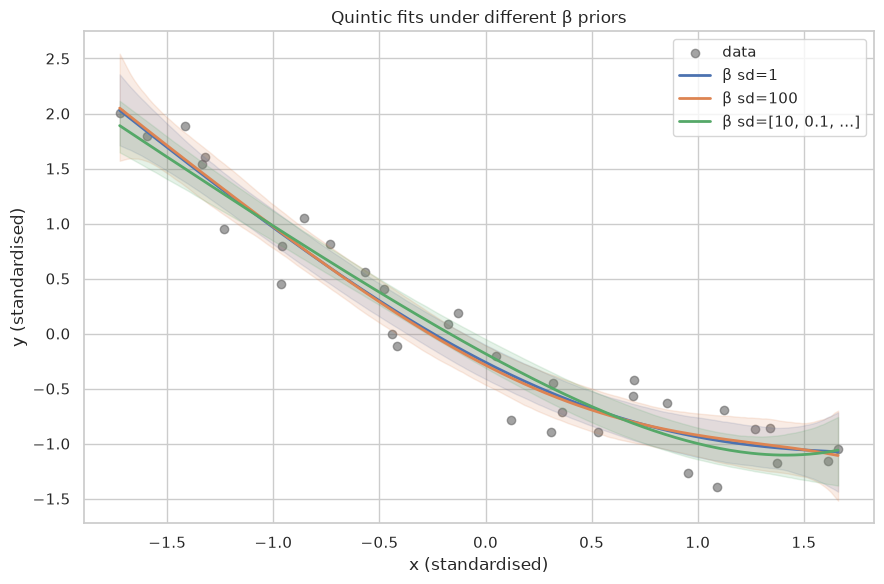

In [9]:
xg = np.linspace(x.min(), x.max(), 200)
xg_c = (np.vstack([xg**i for i in range(1, ORDER + 1)]) - x_mean) / x_std

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_c[0], y_c, alpha=0.6, color="0.4", label="data")
for i, (name, idata) in enumerate(idatas.items()):
    post = idata.posterior
    alpha = post["alpha"].to_numpy().reshape(-1)
    beta = post["beta"].to_numpy().reshape(-1, ORDER)
    mu = alpha[:, None] + beta @ xg_c
    lo, hi = np.percentile(mu, [3, 97], axis=0)
    ax.plot(xg_c[0], mu.mean(0), color=f"C{i}", lw=2, label=name)
    ax.fill_between(xg_c[0], lo, hi, color=f"C{i}", alpha=0.15)
ax.set(title="Quintic fits under different β priors", xlabel="x (standardised)", ylabel="y (standardised)")
ax.legend()
fig.tight_layout()

### Posterior predictive densities

As in the notes: for each model overlay a sample of posterior predictive densities (thin grey), their mean (dashed), and the observed density (black), all via `az.kde` on a shared grid.

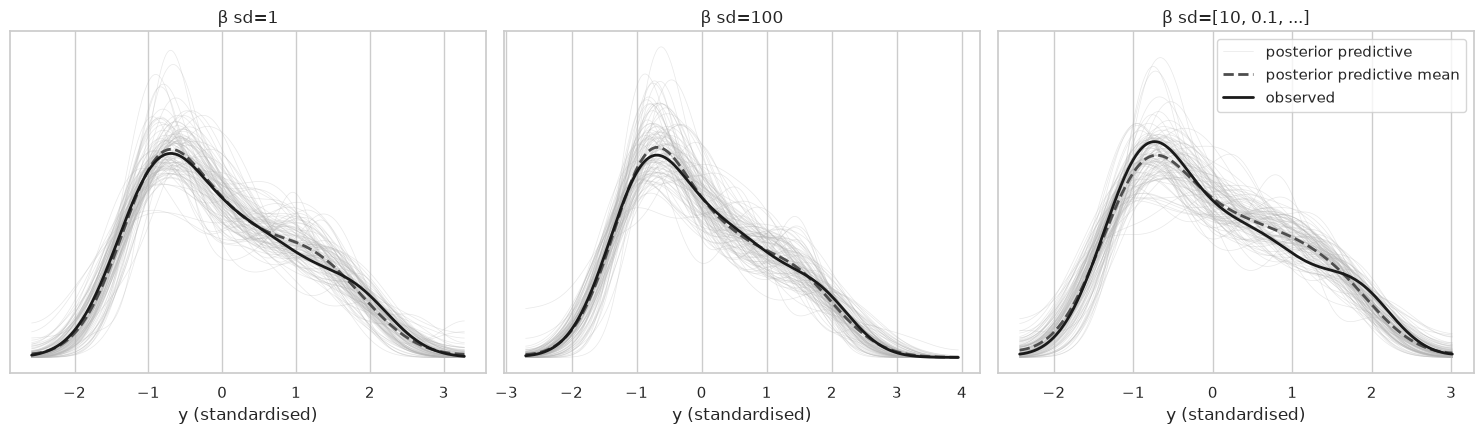

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (name, idata) in zip(axes, idatas.items()):
    obs = idata.observed_data["y"].to_numpy()
    pp = idata.posterior_predictive["y"].to_numpy().reshape(-1, len(obs))

    lims = (pp.min(), pp.max())
    densities = []
    for i, draw in enumerate(rng.permutation(pp)[:N_PP_SAMPLES]):
        grid, density, _ = az.kde(draw, custom_lims=lims)
        ax.plot(grid, density, color="0.7", lw=0.5, alpha=0.3,
                label="posterior predictive" if i == 0 else None)
        densities.append(density)
    ax.plot(grid, np.mean(densities, axis=0), "--", color="0.3", lw=2,
            label="posterior predictive mean")

    grid, density, _ = az.kde(obs, custom_lims=lims)
    ax.plot(grid, density, "k", lw=2, label="observed")
    ax.set(title=name, xlabel="y (standardised)", yticks=[])
axes[-1].legend()
fig.tight_layout()